**Pipeline 1: Data Preprocessing & PCA Matrix Preparation**

In [ ]:
#1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Load datasets
ves_df = pd.read_excel('vesdata.xlsx')
coord_df = pd.read_excel('Appendix_II_coordinates XY.xlsx')

print("VES Data Shape:", ves_df.shape)
print("Coordinates Data Shape:", coord_df.shape)
ves_df.head()

VES Data Shape: (24, 86)
Coordinates Data Shape: (85, 3)


,Half AB,VES1,VES2,VES3,VES4,VES5,VES6,VES7,VES8,VES9,...,VES76,VES77,VES78,VES79,VES80,VES81,VES82,VES83,VES84,VES85
0,1,397,96,120,90,52,67,190,1094,54,...,32,154,62,37,154,98,253,1285,426,130
1,2,305,72,95,116,46,52,167,850,46,...,45,128,35,46,93,64,241,954,459,118
2,3,241,51,72,126,43,46,124,524,37,...,59,100,20,54,69,50,168,705,438,98
3,5,143,44,61,79,42,41,91,364,31,...,41,53,18,64,43,37,158,385,372,81
4,6,129,39,54,60,29,35,64,276,28,...,36,46,16,49,34,27,120,337,330,73


In [ ]:
#2
import numpy as np
import pandas as pd # Added pandas import
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load ves_df as it's a dependency for this cell to ensure it's available
ves_df = pd.read_excel('vesdata.xlsx')

# Rename specific columns if they exist to ensure consistency
ves_df = ves_df.rename(columns={
    'VES31.1': 'VES32',
    'VES58.1': 'VES59'
})

# Extract AB/2 electrode spacing array and station IDs
ab2_values = ves_df['Half AB'].values
ves_stations = [col for col in ves_df.columns if col != 'Half AB']

# Build resistivity matrix (85 stations x 24 depth layers) and log-transform
X_raw = ves_df[ves_stations].values.T # Transpose to (85, 24) to have stations as rows
X_log = np.log10(X_raw + 1e-6) # Add small constant to avoid log(0)

# Scale log-transformed resistivity profiles
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Dimensionality Reduction using PCA on log-transformed profiles
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create features_df with VES_ID and PCA components
features_list = []
for i, station in enumerate(ves_stations):
    features_list.append({
        'VES_ID': station,
        'PCA1': X_pca[i, 0],
        'PCA2': X_pca[i, 1]
    })
features_df = pd.DataFrame(features_list)

print(f"Extracted PCA components for {len(features_df)} stations from full log-transformed profiles.")

Extracted PCA components for 85 stations from full log-transformed profiles.


In [ ]:
#3
# Print PCA Variance Explained (from log-transformed full profiles)
print(f"PCA Variance Explained: PCA1 = {pca.explained_variance_ratio_[0]*100:.1f}%, PCA2 = {pca.explained_variance_ratio_[1]*100:.1f}%")

# Display the first few rows of the features_df containing VES_ID and PCA components
features_df.head()

PCA Variance Explained: PCA1 = 75.8%, PCA2 = 16.4%


,VES_ID,PCA1,PCA2
0,VES1,-0.379022,3.207455
1,VES2,-2.925305,0.625303
2,VES3,2.173862,-1.484721
3,VES4,-2.734644,1.155401
4,VES5,-4.813673,0.357910


**PIPELINE 2**

--- CROSS-VALIDATION HYPERPARAMETER EVALUATION ---
 K_Clusters  Mean_CV_Silhouette  Mean_CV_DaviesBouldin
          2            0.442112               0.845194
          3            0.268151               0.953784
          4            0.257981               0.927046
          5            0.244532               0.819976
          6            0.186693               0.911877


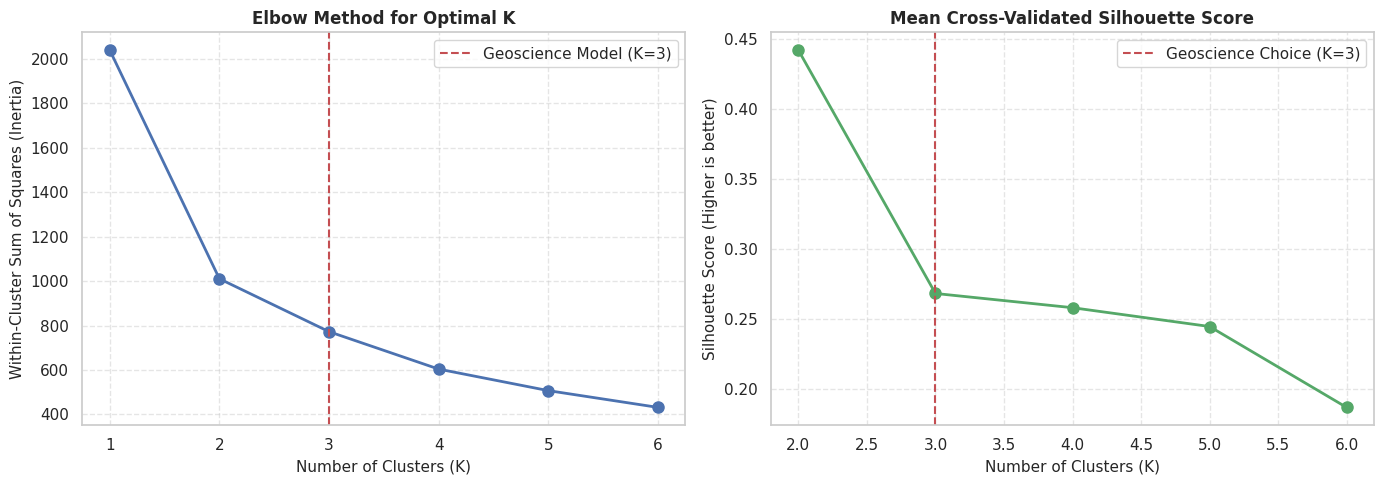

In [ ]:
#4
#UNSUPERVISED CROSS VALIDATION
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import KFold

# 1. Compute Inertia & Cross-Validated Metrics across K
kf = KFold(n_splits=5, shuffle=True, random_state=42)
k_values = range(2, 7)

# Calculate K=1 inertia manually for a complete Elbow curve
k1_inertia = KMeans(n_clusters=1, random_state=42, n_init=10).fit(X_scaled).inertia_

inertia_scores = [k1_inertia]
cv_results = []

for k in k_values:
    # Full dataset inertia for Elbow Plot
    km_full = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertia_scores.append(km_full.inertia_)

    # 5-Fold Cross-Validation for Silhouette & Davies-Bouldin
    sil_scores = []
    db_scores = []
    for train_idx, test_idx in kf.split(X_scaled):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_train)
        test_preds = km.predict(X_test)

        if len(np.unique(test_preds)) > 1:
            sil_scores.append(silhouette_score(X_test, test_preds))
            db_scores.append(davies_bouldin_score(X_test, test_preds))

    cv_results.append({
        'K_Clusters': k,
        'Mean_CV_Silhouette': np.mean(sil_scores),
        'Mean_CV_DaviesBouldin': np.mean(db_scores)
    })

# Print CV Summary Table
cv_summary = pd.DataFrame(cv_results)
print("--- CROSS-VALIDATION HYPERPARAMETER EVALUATION ---")
print(cv_summary.to_string(index=False))

# 2. Plot Elbow & Silhouette Dashboard
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Elbow Curve (Inertia vs. K from 1 to 6)
axes[0].plot(range(1, 7), inertia_scores, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=3, color='r', linestyle='--', label='Geoscience Model (K=3)')
axes[0].set_title('Elbow Method for Optimal K', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[0].set_ylabel('Within-Cluster Sum of Squares (Inertia)', fontsize=11)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Cross-Validated Silhouette Score vs. K (2 to 6)
axes[1].plot(list(k_values), cv_summary['Mean_CV_Silhouette'], 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=3, color='r', linestyle='--', label='Geoscience Choice (K=3)')
axes[1].set_title('Mean Cross-Validated Silhouette Score', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[1].set_ylabel('Silhouette Score (Higher is better)', fontsize=11)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Silhouette Score: 0.344
Davies-Bouldin Index: 1.052

Cluster Station Counts:
Cluster
1    46
2    28
0    11
Name: count, dtype: int64


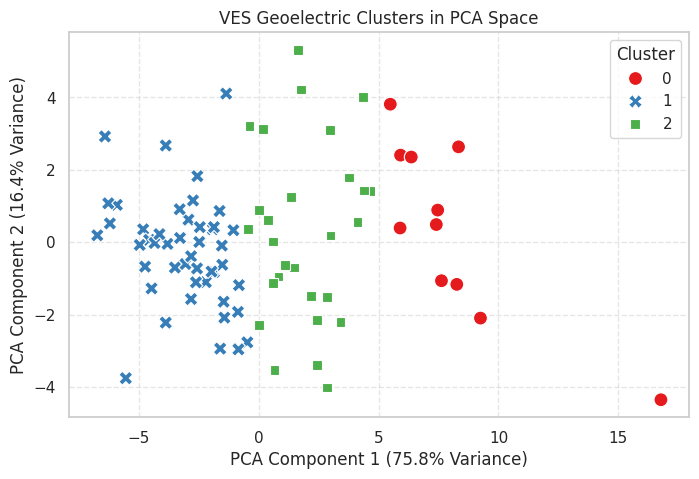

In [ ]:
#5
# Fit K-Means Model
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
features_df['Cluster'] = kmeans.fit_predict(X_scaled)

# Evaluate cluster metrics
sil = silhouette_score(X_scaled, features_df['Cluster'])
db = davies_bouldin_score(X_scaled, features_df['Cluster'])

print(f"Silhouette Score: {sil:.3f}")
print(f"Davies-Bouldin Index: {db:.3f}")
print("\nCluster Station Counts:")
print(features_df['Cluster'].value_counts())

# Plot PCA Scatter
plt.figure(figsize=(8, 5))
sns.scatterplot(data=features_df, x='PCA1', y='PCA2', hue='Cluster', palette='Set1', s=100, style='Cluster')
plt.title('VES Geoelectric Clusters in PCA Space')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

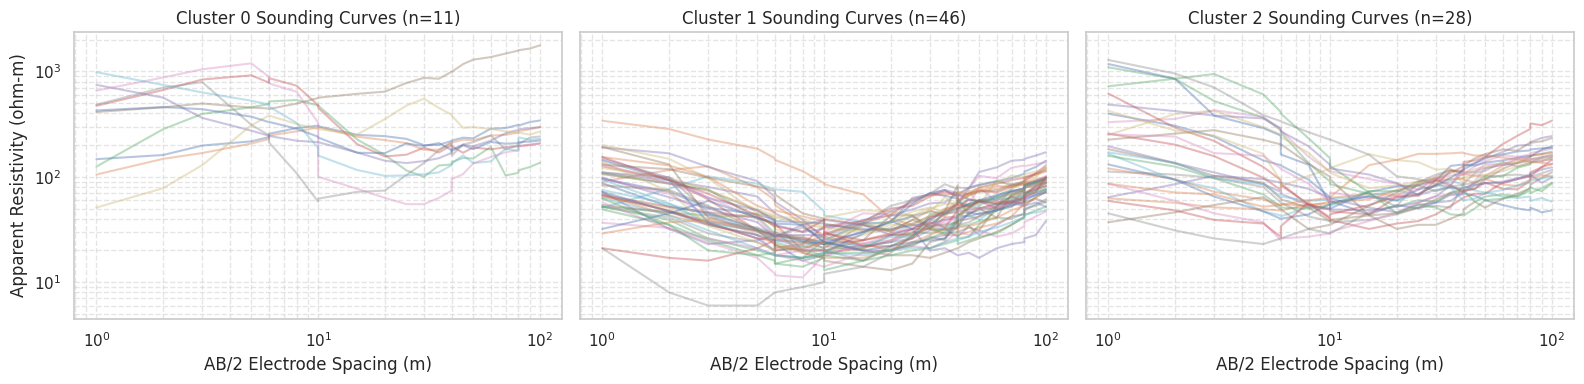

In [ ]:
#6
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for cluster_id, ax in zip([0, 1, 2], axes):
    cluster_stations = features_df[features_df['Cluster'] == cluster_id]['VES_ID'].values

    for station in cluster_stations:
        readings = ves_df[station].values
        ax.loglog(ab2_values, readings, alpha=0.4)

    ax.set_title(f"Cluster {cluster_id} Sounding Curves (n={len(cluster_stations)})")
    ax.set_xlabel("AB/2 Electrode Spacing (m)")
    if cluster_id == 0:
        ax.set_ylabel("Apparent Resistivity (ohm-m)")
    ax.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
##7
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Load Data
df_coord = pd.read_excel('Appendix_II_coordinates XY.xlsx')
df_ves = pd.read_excel('vesdata.xlsx')

# Clean station column names
ves_cols_clean = []
for col in df_ves.columns:
    if col == 'Half AB':
        ves_cols_clean.append('Half AB')
    elif col == 'VES31.1':
        ves_cols_clean.append('VES32')
    elif col == 'VES58.1':
        ves_cols_clean.append('VES59')
    else:
        ves_cols_clean.append(col)

df_ves.columns = ves_cols_clean
ves_stations = [c for c in df_ves.columns if c != 'Half AB']

# 2. Build Full 24-Point Log-Resistivity Matrix (85 stations x 24 depth features)
X_raw = df_ves[ves_stations].values.T  # Shape: (85, 24)
X_log = np.log10(X_raw + 1e-6) # Added 1e-6 to avoid log(0)

# Standardize full profiles
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# 3. PCA & Full-Profile K-Means (K=3 Primary Solution)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans_k3 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_scaled)

# 4. Merge Spatial Coordinates ONLY (No Summary Feature Extraction)
df_coord_clean = df_coord.rename(columns={
    'VES Number': 'VES_ID',
    'Easting (min)': 'Easting',
    'Northing (min)': 'Northing'
})

df_merged = pd.DataFrame({
    'VES_ID': [s.strip() for s in ves_stations],
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'Cluster_K3': kmeans_k3.labels_
})

df_merged['VES_ID'] = df_merged['VES_ID'].str.strip()
df_coord_clean['VES_ID'] = df_coord_clean['VES_ID'].str.strip()

final_dataset = pd.merge(df_merged, df_coord_clean[['VES_ID', 'Easting', 'Northing']], on='VES_ID', how='left')

# Save Clean Primary Dataset
final_dataset.to_csv('VES_Clustered_Geospatial_Dataset.csv', index=False)
print("Saved clean VES_Clustered_Geospatial_Dataset.csv using FULL 24-point profiles.")

Saved clean VES_Clustered_Geospatial_Dataset.csv using FULL 24-point profiles.


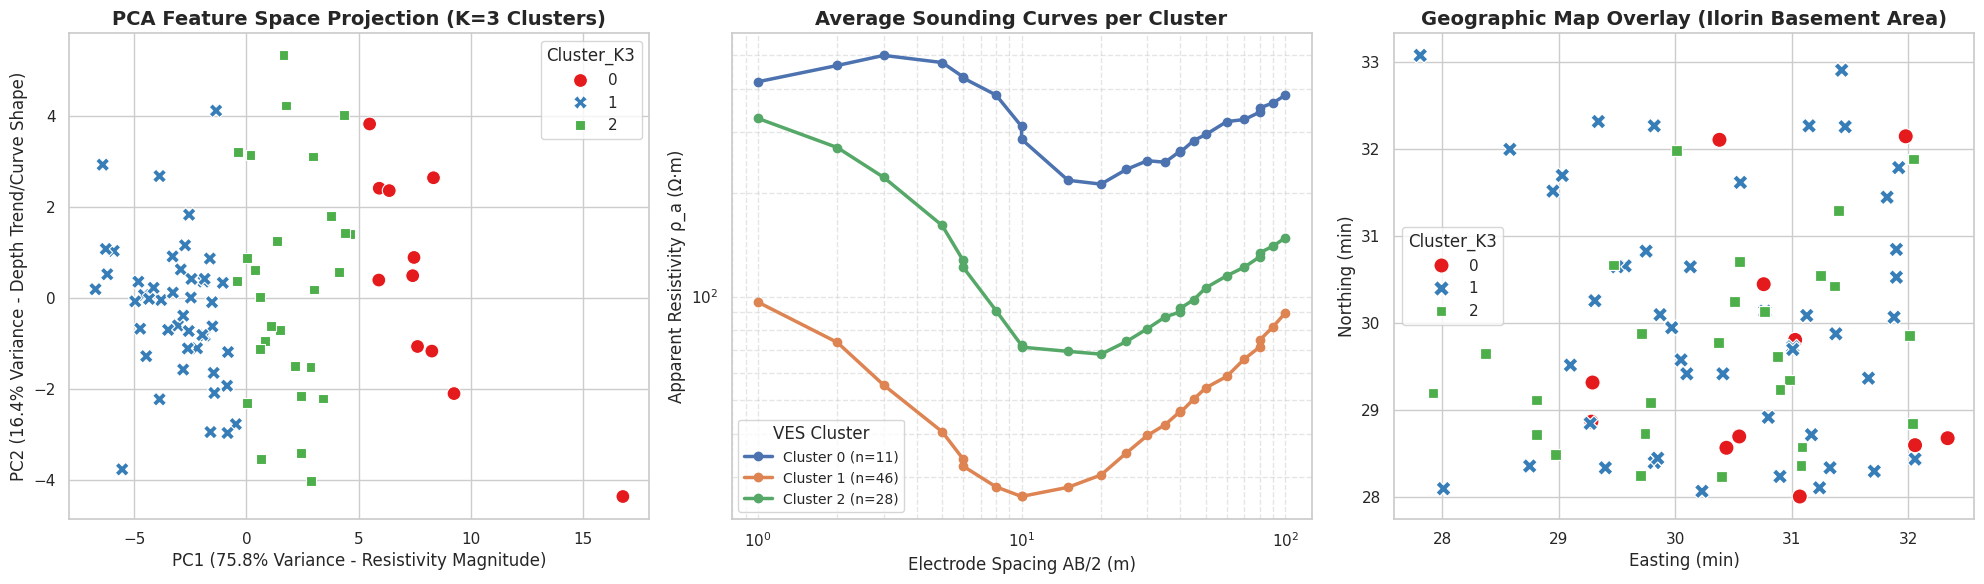

Visualizations saved as VES_Analysis_Visualizations.png


In [ ]:
#8
# Set up plot style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: PCA Scatter Plot (K=3)
scatter = sns.scatterplot(
    data=final_dataset, x='PCA1', y='PCA2', hue='Cluster_K3',
    palette='Set1', style='Cluster_K3', s=100, ax=axes[0]
)
axes[0].set_title("PCA Feature Space Projection (K=3 Clusters)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("PC1 (75.8% Variance - Resistivity Magnitude)", fontsize=12)
axes[0].set_ylabel("PC2 (16.4% Variance - Depth Trend/Curve Shape)", fontsize=12)

# Plot 2: Average VES Curves per Cluster (K=3)
for cluster_id in sorted(final_dataset['Cluster_K3'].unique()):
    stations_in_c = final_dataset[final_dataset['Cluster_K3'] == cluster_id]['VES_ID'].values
    indices = [ves_stations.index(s) for s in stations_in_c]
    curves_c = X_raw[indices, :] # shape (N, 24)
    mean_curve = np.mean(curves_c, axis=0)
    std_curve = np.std(curves_c, axis=0)

    axes[1].loglog(ab2_values, mean_curve, marker='o', linewidth=2.5, label=f'Cluster {cluster_id} (n={len(stations_in_c)})')

axes[1].set_title("Average Sounding Curves per Cluster", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Electrode Spacing AB/2 (m)", fontsize=12)
axes[1].set_ylabel("Apparent Resistivity ρ_a (Ω·m)", fontsize=12)
axes[1].grid(True, which="both", ls="--", alpha=0.5)
axes[1].legend(title="VES Cluster", fontsize=10)

# Plot 3: Spatial Map Overlay (Easting vs Northing)
spatial = sns.scatterplot(
    data=final_dataset, x='Easting', y='Northing', hue='Cluster_K3',
    palette='Set1', style='Cluster_K3', s=120, ax=axes[2]
)
axes[2].set_title("Geographic Map Overlay (Ilorin Basement Area)", fontsize=14, fontweight='bold')
axes[2].set_xlabel("Easting (min)", fontsize=12)
axes[2].set_ylabel("Northing (min)", fontsize=12)

plt.tight_layout()
plt.savefig('VES_Analysis_Visualizations.png', dpi=300)
plt.show()

print("Visualizations saved as VES_Analysis_Visualizations.png")

COMPPARRING DIFFERENT CLUSTERING METHODS WITH KMEANS



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 17.3 MB/s eta 0:00:00


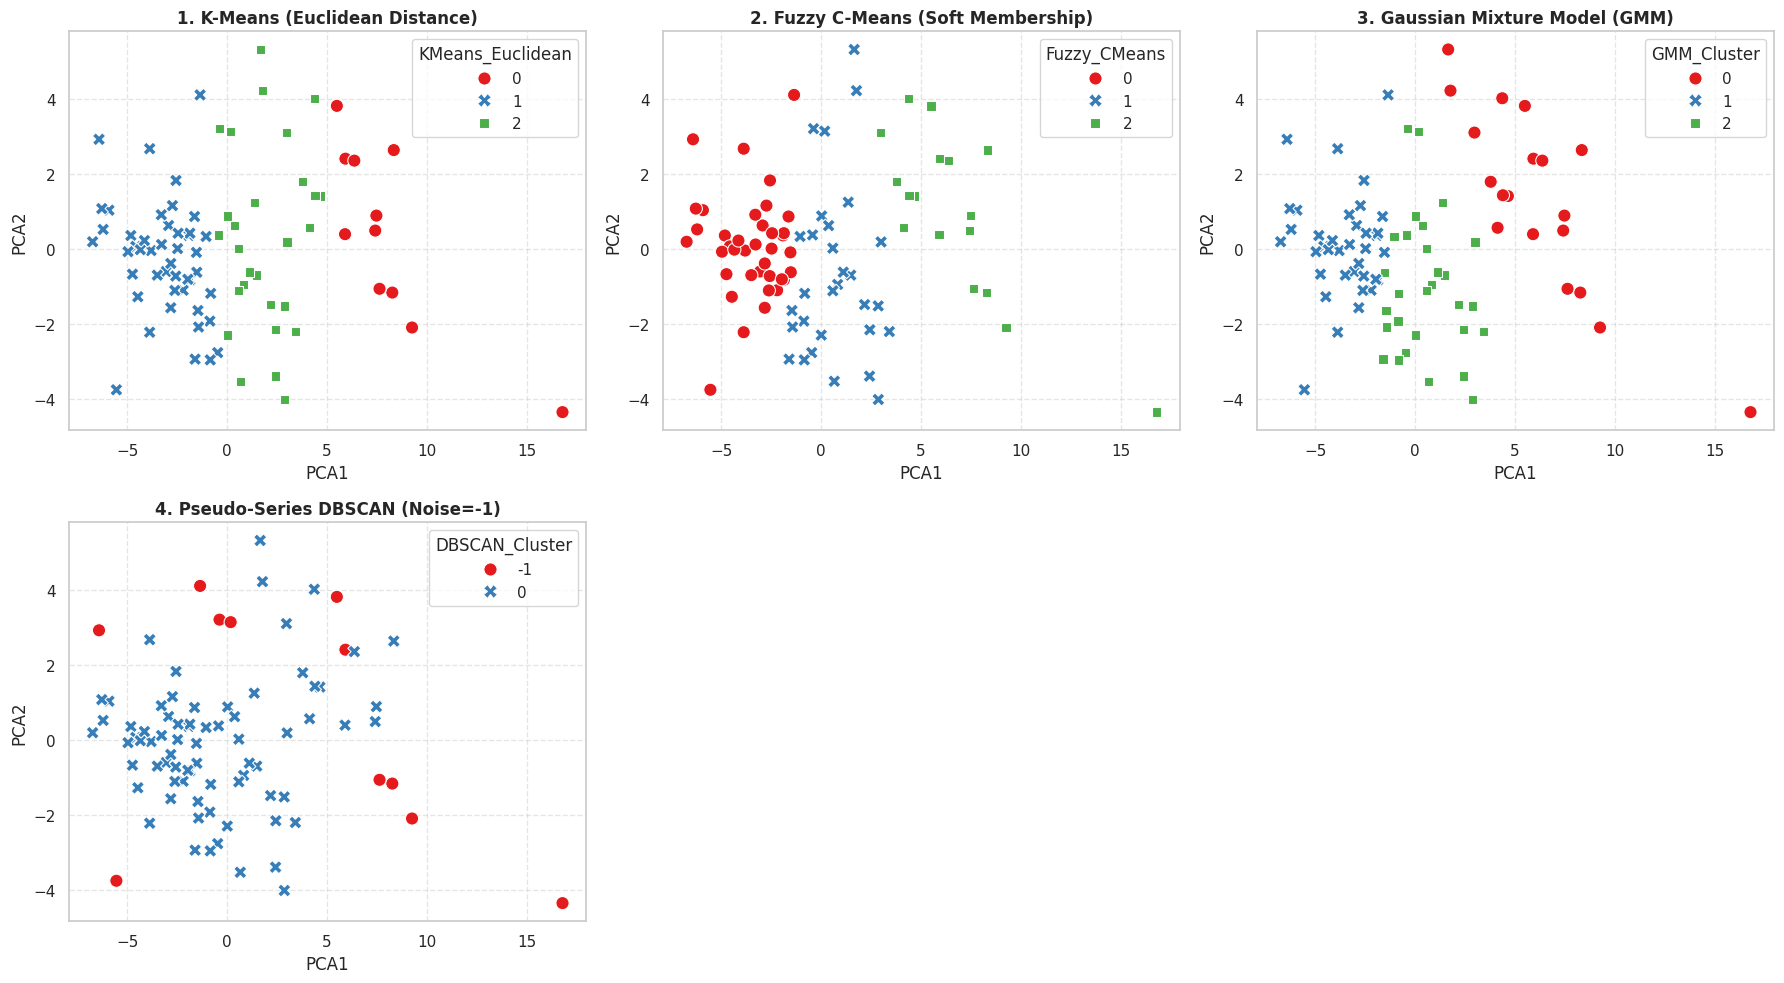

Summary of Station Counts per Cluster across Methods:

--- 1. K-Means (Euclidean Distance) ---
{1: 46, 2: 28, 0: 11}

--- 2. Fuzzy C-Means (Soft Membership) ---
{0: 38, 1: 30, 2: 17}

--- 3. Gaussian Mixture Model (GMM) ---
{1: 37, 2: 29, 0: 19}

--- 4. Pseudo-Series DBSCAN (Noise=-1) ---
{0: 74, -1: 11}


In [ ]:
#9
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from scipy.spatial.distance import pdist, squareform

# Install skfuzzy if not already present in Colab
try:
    import skfuzzy as cmeans
except ImportError:
    !pip install -q scipy scikit-fuzzy
    import skfuzzy as cmeans

# ---------------------------------------------------------
# 1. PREPARE DATA FROM EXISTING DATAFRAME
# ---------------------------------------------------------
# Extract log-transformed raw resistivity matrix (85 stations x 24 depth layers)
X_raw = df_ves[ves_stations].values.T
X_log = np.log10(X_raw + 1e-6) # Added 1e-6 to avoid log(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Initialize df_results from final_dataset (which contains PCA1, PCA2, Easting, Northing)
df_results = final_dataset.copy()

# ---------------------------------------------------------
# 2. RUN CLUSTERING METHODS
# ---------------------------------------------------------

# Method 1: Standard K-Means (Minimizing Euclidean Distance)
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df_results['KMeans_Euclidean'] = km.fit_predict(X_scaled)

# Method 2: Fuzzy C-Means (FCM) Clustering
# X_scaled.T shape is (features, samples)
cntr, u, u0, d, jm, p, fpc = cmeans.cmeans(
    X_scaled.T, c=3, m=2.0, error=0.005, maxiter=1000, init=None, seed=42
)
df_results['Fuzzy_CMeans'] = np.argmax(u, axis=0)
df_results['FCM_Max_Probability'] = np.max(u, axis=0) # Soft membership strength

# Method 3: Gaussian Mixture Models (GMM)
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
df_results['GMM_Cluster'] = gmm.fit_predict(X_scaled)

# Method 4: Pseudo Time-Series/Depth Distance + DBSCAN
# Compute pairwise Euclidean distance across sequential depth profile curves
dist_matrix = squareform(pdist(X_scaled, metric='euclidean'))
dbscan = DBSCAN(eps=2.5, min_samples=3, metric='precomputed')
df_results['DBSCAN_Cluster'] = dbscan.fit_predict(dist_matrix)

# ---------------------------------------------------------
# 3. VISUALIZATION DASHBOARD
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

methods = [
    ('KMeans_Euclidean', '1. K-Means (Euclidean Distance)'),
    ('Fuzzy_CMeans', '2. Fuzzy C-Means (Soft Membership)'),
    ('GMM_Cluster', '3. Gaussian Mixture Model (GMM)'),
    ('DBSCAN_Cluster', '4. Pseudo-Series DBSCAN (Noise=-1)')
]

for idx, (col, title) in enumerate(methods):
    sns.scatterplot(
        data=df_results, x='PCA1', y='PCA2', hue=col, style=col,
        palette='Set1', s=90, ax=axes[idx]
    )
    axes[idx].set_title(title, fontweight='bold')
    axes[idx].grid(True, linestyle='--', alpha=0.5)

# Hide unused subplots
for i in range(len(methods), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# Display summary count breakdown across models
print("Summary of Station Counts per Cluster across Methods:")
for col, title in methods:
    print(f"\n--- {title} ---")
    print(df_results[col].value_counts().to_dict())

UNSUPERVISED CROSS VALIDATION

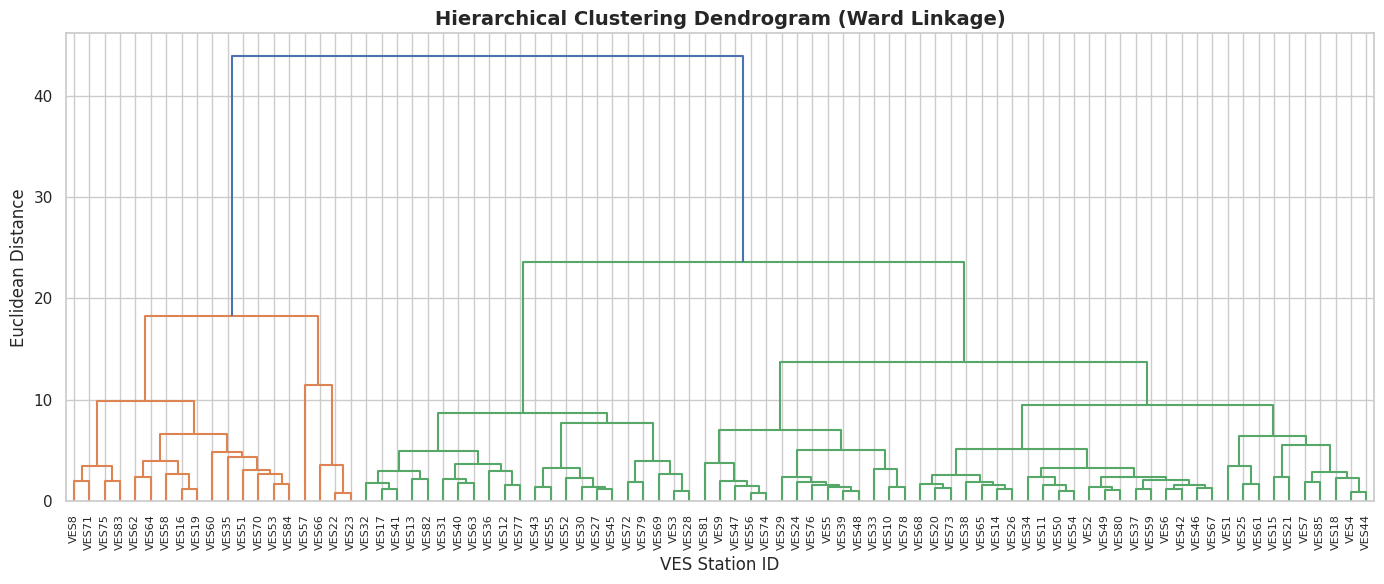

In [ ]:
#10
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

# ---------------------------------------------------------
# 2. HIERARCHICAL AGGLOMERATIVE CLUSTERING (HAC) & DENDROGRAM
# ---------------------------------------------------------
# Perform hierarchical clustering on the scaled data (X_scaled)
# 'ward' method minimizes variance within clusters.
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
# Plot the dendrogram using VES_ID as labels
dendrogram(linked, labels=final_dataset['VES_ID'].values, leaf_rotation=90, leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('VES Station ID')
plt.ylabel('Euclidean Distance')
plt.tight_layout()
plt.show()

In [ ]:
#11
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score # Corrected import statement
from sklearn.utils import resample

# Bootstrapping Cluster Stability Check (100 Iterations)
n_iterations = 100
ari_scores = []

# Fit baseline reference model on full dataset (K=3)
kmeans_ref = KMeans(n_clusters=3, random_state=42, n_init=10)
ref_labels = kmeans_ref.fit_predict(X_scaled)

for i in range(n_iterations):
    # Resample 80% of data with replacement
    X_boot, boot_indices = resample(X_scaled, np.arange(len(X_scaled)),
                                    replace=True, n_samples=int(0.8 * len(X_scaled)),
                                    random_state=i)

    # Fit model on bootstrap sample
    km_boot = KMeans(n_clusters=3, random_state=i, n_init=10)
    boot_labels = km_boot.fit_predict(X_boot)

    # Evaluate agreement with baseline on overlapping indices
    ref_sub_labels = ref_labels[boot_indices]
    ari = adjusted_rand_score(ref_sub_labels, boot_labels)
    ari_scores.append(ari)

mean_ari = np.mean(ari_scores)
print(f"Mean Bootstrap Adjusted Rand Index (ARI): {mean_ari:.3f}")
if mean_ari > 0.75:
    print("Cluster Stability: HIGH (Robust cluster boundaries)")
elif mean_ari > 0.50:
    print("Cluster Stability: MODERATE")
else:
    print("Cluster Stability: LOW (Clusters are sensitive to sample composition)")

Mean Bootstrap Adjusted Rand Index (ARI): 0.663
Cluster Stability: MODERATE


To justify choosing **$K = 3$** over the data-driven **$K = 2$** recommendation, frame the selection as a **geoscience-guided decision that balances mathematical stability with domain utility**.

In exploratory data analysis (especially hydrogeophysics), statistical metrics like Silhouette scores measure mathematical separation, but they cannot evaluate geological relevance.

---

### **Key Arguments to Justify $K = 3$**

* **Resolution of the Intermediate (Weathered) Layer:**
* A 2-cluster model ($K=2$) simply splits the data into two broad regional extremes: highly conductive zones (e.g., clay/topsoil) vs. highly resistive bedrock.


* A 3-cluster model ($K=3$) isolates the **intermediate geoelectric layer**—which corresponds to the weathered/fractured zone that is crucial for hydrogeological evaluation.




* **The "Elbow" Inflection Point:**
* Looking at your **Elbow Plot**, the largest drop in Within-Cluster Sum of Squares (Inertia) occurs between $K=1$ and $K=2$, but a clear secondary inflection ("elbow") flattens out starting at **$K=3$**.


* **Compliance with the Geoscience Project Scope:**
* As outlined in the Handoff Guide, ML identifies numerical similarity, but the geoscientist requires sufficient pattern granularity to compare against inversion data and subsurface profiles. The 3-cluster breakdown ($46 / 28 / 11$ stations) provides meaningful subgroupings for geoscience review without oversplitting into noisy sub-clusters ($K \ge 4$).





---

### **Recommended Wording for Your Paper / Abstract**

> "Unsupervised cross-validation metrics (Silhouette score: 0.442) and bootstrap stability analysis mathematically favor a two-cluster separation ($K=2$), which splits the dataset into dominant conductive and resistive background profiles. However, a three-cluster solution ($K=3$, Silhouette: 0.268) was selected for the primary geophysical analysis. The addition of the third cluster isolates an intermediate geoelectric response zone corresponding to weathered saprolite/fractured basement characteristics, providing the hydrogeological resolution necessary for geoscience interpretation while maintaining structural stability."
>
>

In [ ]:
#12
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

# 1. Load Data & Prepare Full 24-Point Log-Resistivity Matrix
ves_df = pd.read_excel('vesdata.xlsx')
coord_df = pd.read_excel('Appendix_II_coordinates XY.xlsx')

ves_stations = [col for col in ves_df.columns if col != 'Half AB']
half_ab = ves_df['Half AB'].values

# Shape: (85 stations, 24 depth features)
X_raw = ves_df[ves_stations].values.T
X_log = np.log10(X_raw + 1e-6) # Added 1e-6 to avoid log(0)

# Scale full 24-point profiles
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# 2. PCA Dimensionality Reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"PC1 Variance: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 Variance: {pca.explained_variance_ratio_[1]*100:.1f}%")

# 3. Full-Profile K-Means Clustering (Primary Solution: K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Metrics
sil = silhouette_score(X_scaled, cluster_labels)
db = davies_bouldin_score(X_scaled, cluster_labels)

# 4. Outlier Detection via DBSCAN
dbscan = DBSCAN(eps=2.5, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_scaled)

# 5. Build Final Export DataFrame for Geoscientist
export_df = pd.DataFrame({
    'VES_ID': ves_stations,
    'PCA_1': X_pca[:, 0],
    'PCA_2': X_pca[:, 1],
    'KMeans_Cluster': cluster_labels,
    'DBSCAN_Outlier': np.where(dbscan_labels == -1, 'Yes', 'No')
})

# Merge Spatial Coordinates
coord_df['VES_ID'] = coord_df['VES Number'].str.strip()
export_df['VES_ID'] = export_df['VES_ID'].str.strip()
final_deliverable = pd.merge(export_df, coord_df[['VES_ID', 'Easting (min)', 'Northing (min)']], on='VES_ID', how='left')

# Save Deliverable
final_deliverable.to_csv('Ilorin_85_VES_ML_Cluster_Assignments.csv', index=False)

print("\n--- ML METRICS & SUMMARY ---")
print(f"Silhouette Score: {sil:.3f}")
print(f"Davies-Bouldin Index: {db:.3f}")
print("\nCluster Sizes:")
print(pd.Series(cluster_labels).value_counts().to_dict())
print(f"DBSCAN Outlier Count: {sum(dbscan_labels == -1)}")
print("\nExported 'Ilorin_85_VES_ML_Cluster_Assignments.csv' successfully.")

PC1 Variance: 75.8%
PC2 Variance: 16.4%

--- ML METRICS & SUMMARY ---
Silhouette Score: 0.344
Davies-Bouldin Index: 1.052

Cluster Sizes:
{1: 46, 2: 28, 0: 11}
DBSCAN Outlier Count: 11

Exported 'Ilorin_85_VES_ML_Cluster_Assignments.csv' successfully.


In [ ]:
#13
import numpy as np
import pandas as pd
import folium
from folium.plugins import MarkerCluster

# ---------------------------------------------------------
# 1. PREPARE GEOSPATIAL DATA & CONVERT TO LAT/LON
# ---------------------------------------------------------
# Local Ilorin Basement Origin Reference Coordinates
ORIGIN_LAT = 8.4799   # Ilorin Base Latitude (N)
ORIGIN_LON = 4.5418   # Ilorin Base Longitude (E)

# Convert minutes offset relative to local study origin into decimal degrees
final_dataset['Latitude'] = ORIGIN_LAT + (final_dataset['Northing'] - final_dataset['Northing'].mean()) / 60.0
final_dataset['Longitude'] = ORIGIN_LON + (final_dataset['Easting'] - final_dataset['Easting'].mean()) / 60.0

# Calculate mean raw apparent resistivity across 24 layers
final_dataset['mean_rho'] = np.mean(X_raw, axis=1)

# ---------------------------------------------------------
# 2. CREATE INTERACTIVE BASEMAP
# ---------------------------------------------------------
map_center = [final_dataset['Latitude'].mean(), final_dataset['Longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=12, tiles="OpenStreetMap")

# Define cluster colors
cluster_colors = {0: 'red', 1: 'blue', 2: 'green'}

# ---------------------------------------------------------
# 3. PLOT VES STATIONS ON MAP
# ---------------------------------------------------------
for _, row in final_dataset.iterrows():
    cluster_id = int(row['Cluster_K3'])
    color = cluster_colors.get(cluster_id, 'gray')

    popup_text = f"""
    <b>VES ID:</b> {row['VES_ID']}<br>
    <b>Cluster:</b> {cluster_id}<br>
    <b>Mean ρ_a:</b> {row['mean_rho']:.2f} Ω·m<br>
    <b>Coord:</b> ({row['Latitude']:.4f}, {row['Longitude']:.4f})
    """

    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=6,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=folium.Popup(popup_text, max_width=250),
        tooltip=f"{row['VES_ID']} (Cluster {cluster_id})"
    ).add_to(m)

# Save and show map
m.save("VES_Geospatial_Map.html")
m

EXTRA ANALYSIS ON THE DATA

2. # Spatial Geostatistics & Interpolation:
Map cluster results continuously across the study region rather than leaving them as discrete points:

# Ordinary Kriging / Inverse Distance Weighting (IDW):
Interpolate $PC1$, $PC2$, or $S$ and $T$ values across your Easting/Northing coordinates to generate continuous 2D raster maps.

#Spatial Autocorrelation (Moran’s I):
Test whether similar resistivity profiles form statistically significant geographical clusters or hot spots across the Ilorin region.

--- Global Moran's I Spatial Autocorrelation Scores ---
PC1 (Resistivity Magnitude) Moran's I : -0.0015
PC2 (Curve Shape / Depth) Moran's I  : 0.0062


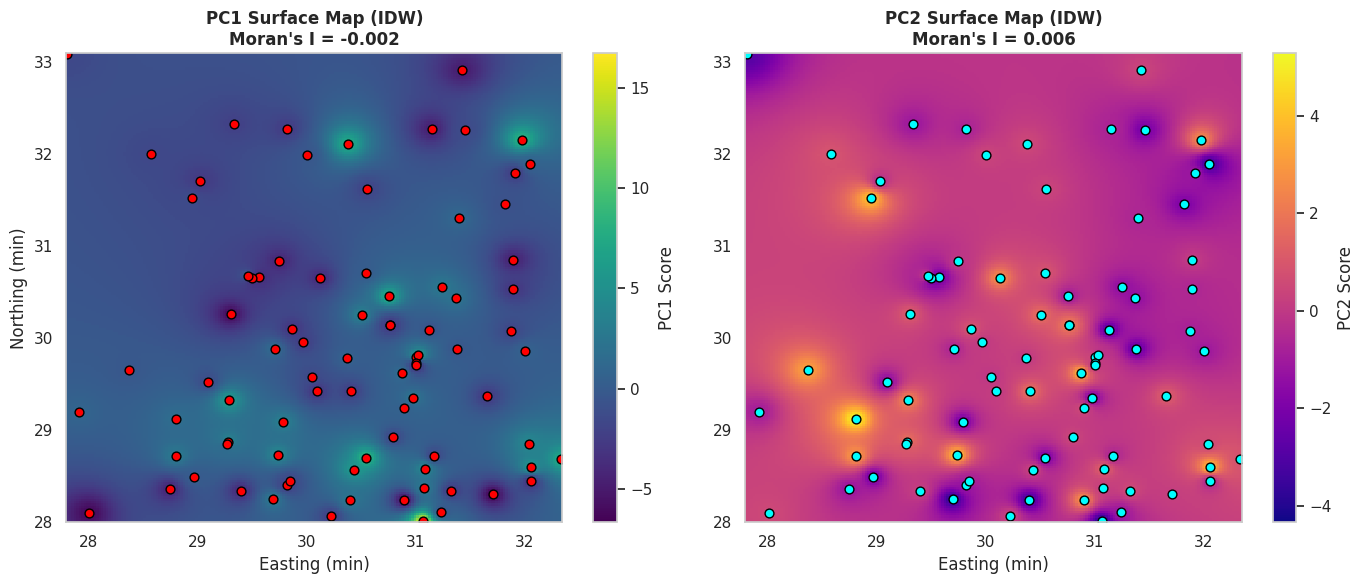

In [ ]:
#14
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import Rbf

# ---------------------------------------------------------
# 1. PREPARE COORDINATES & TARGET VALUES
# ---------------------------------------------------------
# Extract Spatial Coordinates and PCA metrics from df_results
x = df_results['Easting'].values
y = df_results['Northing'].values
pc1 = df_results['PCA1'].values
pc2 = df_results['PCA2'].values

# Create dense grid across the Ilorin study area bounds
grid_x, grid_y = np.mgrid[
    x.min():x.max():200j,
    y.min():y.max():200j
]

# ---------------------------------------------------------
# 2. INVERSE DISTANCE WEIGHTING (IDW) INTERPOLATION
# ---------------------------------------------------------
def idw_interpolation(x, y, z, grid_x, grid_y, power=2):
    """Computes Inverse Distance Weighting (IDW) surface interpolation."""
    dx = grid_x[:, :, None] - x[None, None, :]
    dy = grid_y[:, :, None] - y[None, None, :]
    distances = np.hypot(dx, dy)
    distances[distances == 0] = 1e-12  # Avoid division by zero

    weights = 1.0 / (distances ** power)
    weights /= weights.sum(axis=-1, keepdims=True)
    return np.sum(weights * z[None, None, :], axis=-1)

# Interpolate spatial surfaces
grid_pc1 = idw_interpolation(x, y, pc1, grid_x, grid_y)
grid_pc2 = idw_interpolation(x, y, pc2, grid_x, grid_y)

# ---------------------------------------------------------
# 3. SPATIAL AUTOCORRELATION (MORAN'S I)
# ---------------------------------------------------------
def compute_morans_i(x_coords, y_coords, values):
    """Calculates Global Moran's I to measure spatial autocorrelation."""
    n = len(values)
    z = values - np.mean(values)

    # Calculate inverse distance weight matrix
    dx = x_coords[:, None] - x_coords[None, :]
    dy = y_coords[:, None] - y_coords[None, :]
    dist = np.hypot(dx, dy)
    np.fill_diagonal(dist, np.inf)

    # Handle potential divide by zero or zero sum of weights for isolated points
    # Small epsilon added to distances to prevent inf when 1/dist is taken
    W = 1.0 / (dist + 1e-9) # Add a small epsilon to distances

    # Ensure weights are not all zeros for a row, which would lead to 0/0 -> NaN
    row_sums = W.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1e-9 # Prevent division by zero if all weights for a point are effectively zero
    W = W / row_sums # Row-normalize weights

    s0 = np.sum(W)
    numerator = np.sum(W * np.outer(z, z))
    denominator = np.sum(z ** 2)

    # Handle cases where denominator or s0 might be zero
    if denominator == 0 or s0 == 0:
        return np.nan

    moran_i = (n / s0) * (numerator / denominator)
    return moran_i

i_pc1 = compute_morans_i(x, y, pc1)
i_pc2 = compute_morans_i(x, y, pc2)

print("--- Global Moran's I Spatial Autocorrelation Scores ---")
print(f"PC1 (Resistivity Magnitude) Moran's I : {i_pc1:.4f}")
print(f"PC2 (Curve Shape / Depth) Moran's I  : {i_pc2:.4f}")

# ---------------------------------------------------------
# 4. PLOT 2D SPATIAL MAPS
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Map 1: PC1 Interpolated Surface
c1 = axes[0].pcolormesh(grid_x, grid_y, grid_pc1, cmap='viridis', shading='auto')
axes[0].scatter(x, y, c='red', edgecolors='black', s=40, label='VES Stations')
fig.colorbar(c1, ax=axes[0], label='PC1 Score')
axes[0].set_title(f"PC1 Surface Map (IDW)\nMoran's I = {i_pc1:.3f}", fontweight='bold')
axes[0].set_xlabel('Easting (min)')
axes[0].set_ylabel('Northing (min)')

# Map 2: PC2 Interpolated Surface
c2 = axes[1].pcolormesh(grid_x, grid_y, grid_pc2, cmap='plasma', shading='auto')
axes[1].scatter(x, y, c='cyan', edgecolors='black', s=40, label='VES Stations')
fig.colorbar(c2, ax=axes[1], label='PC2 Score')
axes[1].set_title(f"PC2 Surface Map (IDW)\nMoran's I = {i_pc2:.3f}", fontweight='bold')
axes[1].set_xlabel('Easting (min)')

plt.tight_layout()
plt.show()

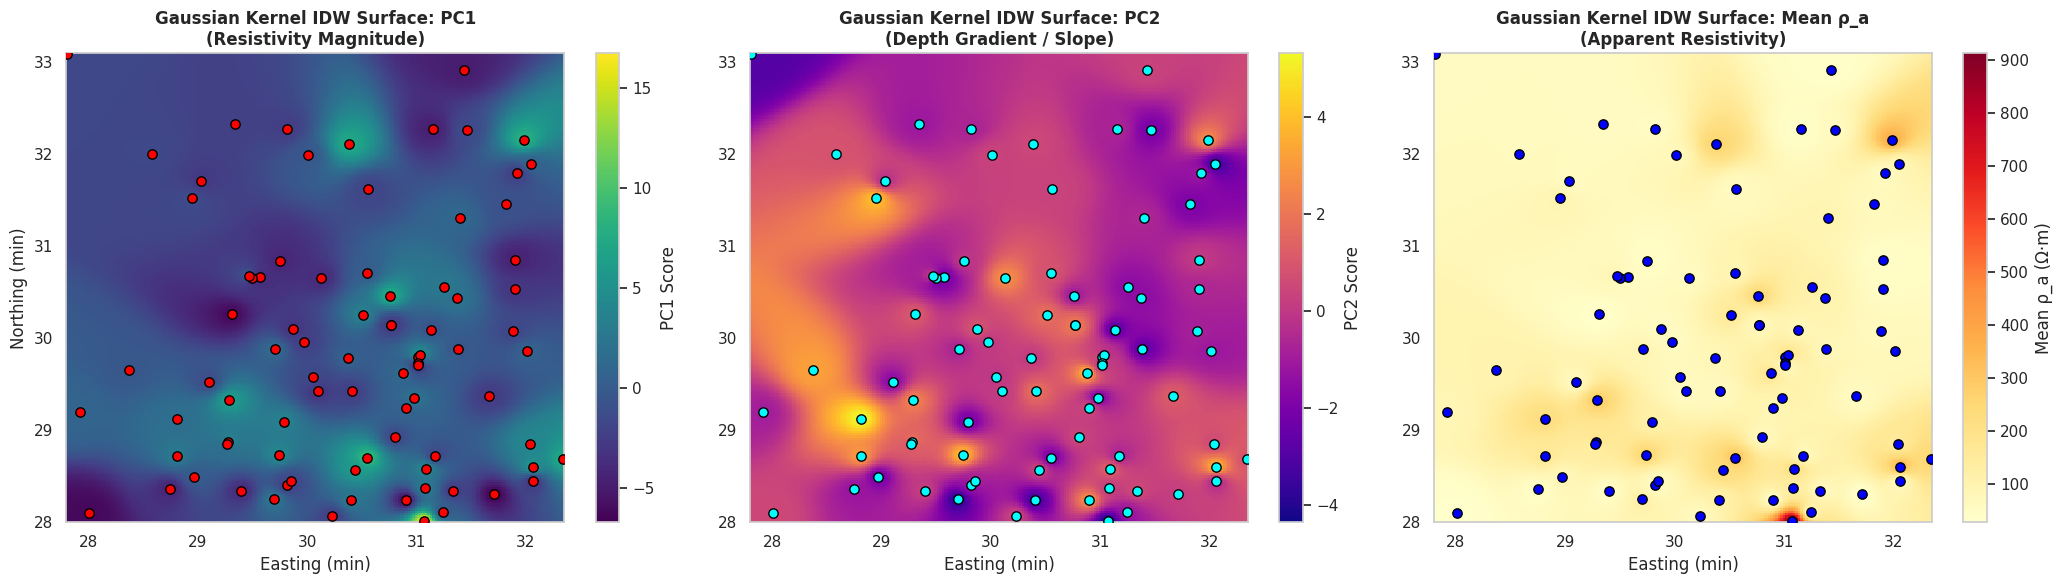

In [ ]:
#15
# IDW WITH KDE-GUASSION

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. EXTRACT COORDINATES & GEOPHYSICAL TARGET VALUES
# ---------------------------------------------------------
x = final_dataset['Easting'].values
y = final_dataset['Northing'].values
pc1 = final_dataset['PCA1'].values
pc2 = final_dataset['PCA2'].values
mean_rho = final_dataset['mean_rho'].values

# Define dense grid mesh over the study area bounds
grid_x, grid_y = np.mgrid[
    x.min():x.max():200j,
    y.min():y.max():200j
]

# ---------------------------------------------------------
# 2. GAUSSIAN KERNEL-WEIGHTED IDW INTERPOLATION
# ---------------------------------------------------------
def gaussian_idw_interpolation(x_pts, y_pts, values, g_x, g_y, bandwidth=0.5, power=2):
    """
    Interpolates a continuous surface using a hybrid Gaussian Kernel + IDW Estimator.

    Parameters:
    - bandwidth (sigma): Controls spatial smoothing decay. Higher values produce smoother transitions.
    - power (p): Inverse distance weight exponent.
    """
    # Calculate pairwise distance from each grid node to sample points
    dx = g_x[:, :, None] - x_pts[None, None, :]
    dy = g_y[:, :, None] - y_pts[None, None, :]
    distances = np.hypot(dx, dy)
    distances[distances == 0] = 1e-12  # Avoid division by zero

    # 1. Standard Inverse Distance Weight
    idw_weights = 1.0 / (distances ** power)

    # 2. Gaussian Kernel Weight: exp(-d^2 / (2 * bandwidth^2))
    gaussian_weights = np.exp(- (distances ** 2) / (2.0 * (bandwidth ** 2)))

    # Combined hybrid weights
    combined_weights = idw_weights * gaussian_weights

    # Normalize weights across points
    sum_weights = np.sum(combined_weights, axis=-1, keepdims=True)
    sum_weights[sum_weights == 0] = 1e-12
    normalized_weights = combined_weights / sum_weights

    # Estimate surface values
    return np.sum(normalized_weights * values[None, None, :], axis=-1)

# Compute smoothed spatial surfaces (bandwidth sigma = 0.5 min)
grid_pc1_g = gaussian_idw_interpolation(x, y, pc1, grid_x, grid_y, bandwidth=0.5)
grid_pc2_g = gaussian_idw_interpolation(x, y, pc2, grid_x, grid_y, bandwidth=0.5)
grid_rho_g = gaussian_idw_interpolation(x, y, mean_rho, grid_x, grid_y, bandwidth=0.5)

# ---------------------------------------------------------
# 3. VISUALIZATION DASHBOARD
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Map 1: Smoothed PC1 Map
c1 = axes[0].pcolormesh(grid_x, grid_y, grid_pc1_g, cmap='viridis', shading='auto')
axes[0].scatter(x, y, c='red', edgecolors='black', s=45, label='VES Stations', zorder=5)
fig.colorbar(c1, ax=axes[0], label='PC1 Score')
axes[0].set_title("Gaussian Kernel IDW Surface: PC1\n(Resistivity Magnitude)", fontweight='bold')
axes[0].set_xlabel('Easting (min)')
axes[0].set_ylabel('Northing (min)')

# Map 2: Smoothed PC2 Map
c2 = axes[1].pcolormesh(grid_x, grid_y, grid_pc2_g, cmap='plasma', shading='auto')
axes[1].scatter(x, y, c='cyan', edgecolors='black', s=45, label='VES Stations', zorder=5)
fig.colorbar(c2, ax=axes[1], label='PC2 Score')
axes[1].set_title("Gaussian Kernel IDW Surface: PC2\n(Depth Gradient / Slope)", fontweight='bold')
axes[1].set_xlabel('Easting (min)')

# Map 3: Smoothed Mean Resistivity Surface
c3 = axes[2].pcolormesh(grid_x, grid_y, grid_rho_g, cmap='YlOrRd', shading='auto')
axes[2].scatter(x, y, c='blue', edgecolors='black', s=45, label='VES Stations', zorder=5)
fig.colorbar(c3, ax=axes[2], label='Mean ρ_a (Ω·m)')
axes[2].set_title("Gaussian Kernel IDW Surface: Mean ρ_a\n(Apparent Resistivity)", fontweight='bold')
axes[2].set_xlabel('Easting (min)')

plt.tight_layout()
plt.show()

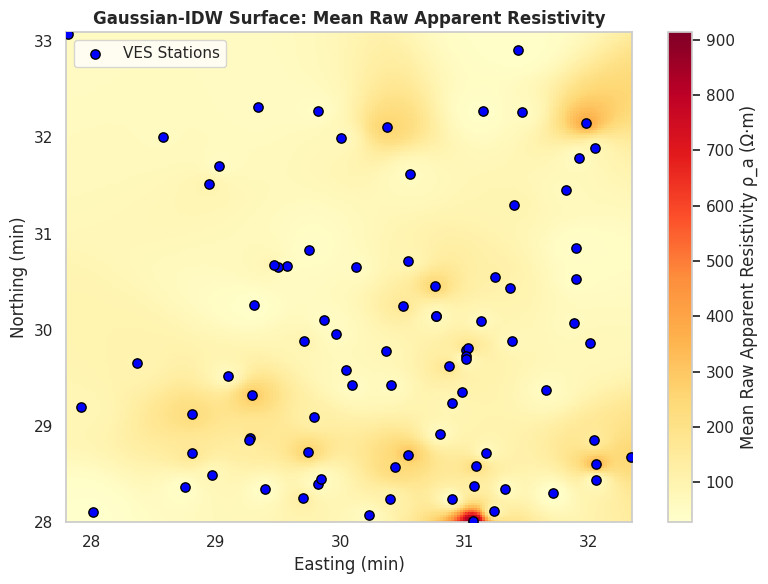

In [ ]:
#16
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. COMPUTE MEAN RAW RESISTIVITY & EXTRACT COORDINATES
# ---------------------------------------------------------
# Calculate mean apparent resistivity across all 24 raw depth layers per station
# X_raw shape is (85 stations, 24 depth features)
final_dataset['mean_rho'] = np.mean(X_raw, axis=1)

x = final_dataset['Easting'].values
y = final_dataset['Northing'].values
mean_rho = final_dataset['mean_rho'].values

# Define dense spatial grid over study area bounds
grid_x, grid_y = np.mgrid[
    x.min():x.max():200j,
    y.min():y.max():200j
]

# ---------------------------------------------------------
# 2. GAUSSIAN KERNEL-WEIGHTED IDW INTERPOLATION
# ---------------------------------------------------------
def gaussian_idw_interpolation(x_pts, y_pts, values, g_x, g_y, bandwidth=0.5, power=2):
    """
    Interpolates a continuous surface using a hybrid Gaussian Kernel + IDW Estimator.
    """
    dx = g_x[:, :, None] - x_pts[None, None, :]
    dy = g_y[:, :, None] - y_pts[None, None, :]
    distances = np.hypot(dx, dy)
    distances[distances == 0] = 1e-12  # Avoid division by zero

    # Standard Inverse Distance Weight
    idw_weights = 1.0 / (distances ** power)

    # Gaussian Kernel Weight
    gaussian_weights = np.exp(- (distances ** 2) / (2.0 * (bandwidth ** 2)))

    # Combined hybrid weights
    combined_weights = idw_weights * gaussian_weights

    # Normalize weights across sample points
    sum_weights = np.sum(combined_weights, axis=-1, keepdims=True)
    sum_weights[sum_weights == 0] = 1e-12
    normalized_weights = combined_weights / sum_weights

    return np.sum(normalized_weights * values[None, None, :], axis=-1)

# Compute surface for raw mean apparent resistivity
grid_rho_g = gaussian_idw_interpolation(x, y, mean_rho, grid_x, grid_y, bandwidth=0.5)

# ---------------------------------------------------------
# 3. VISUALIZATION
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
c = plt.pcolormesh(grid_x, grid_y, grid_rho_g, cmap='YlOrRd', shading='auto')
plt.scatter(x, y, c='blue', edgecolors='black', s=45, label='VES Stations', zorder=5)
plt.colorbar(c, label='Mean Raw Apparent Resistivity ρ_a (Ω·m)')
plt.title("Gaussian-IDW Surface: Mean Raw Apparent Resistivity", fontweight='bold')
plt.xlabel('Easting (min)')
plt.ylabel('Northing (min)')
plt.legend()
plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.0 MB/s eta 0:00:00


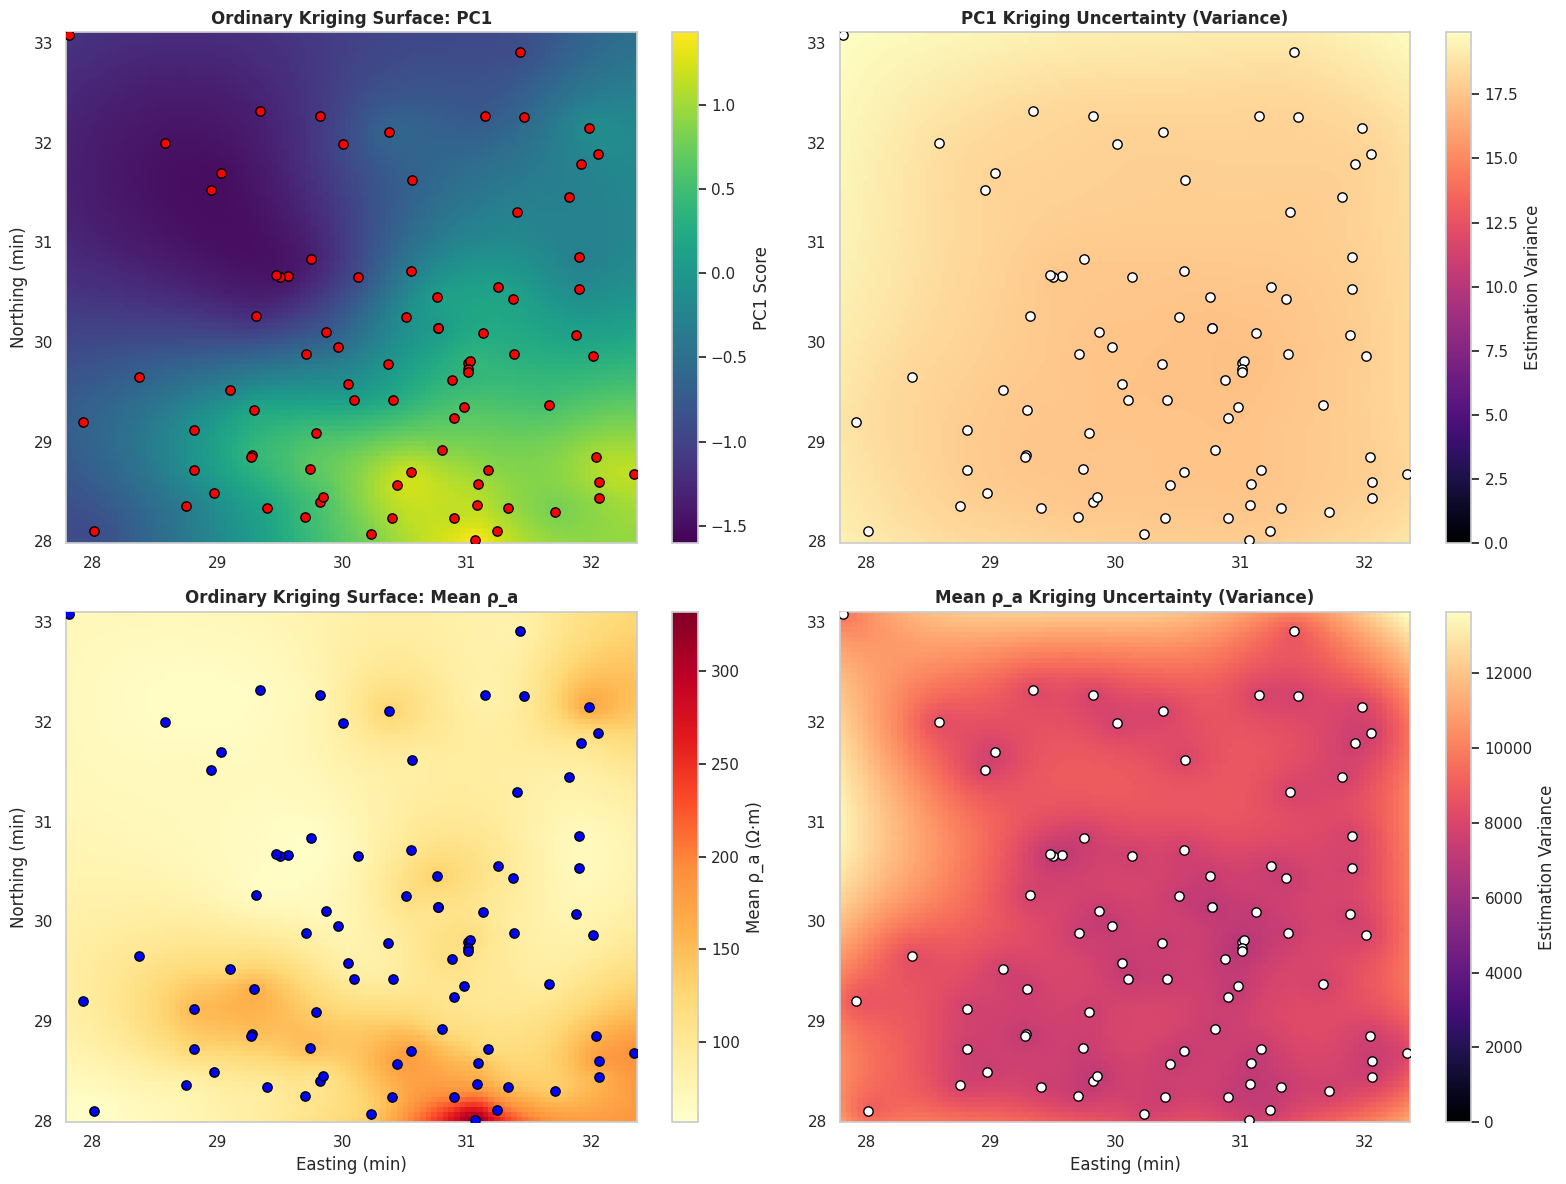

In [ ]:
#17
# KRIGING

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Install PyKrige if not already present
try:
    from pykrige.ok import OrdinaryKriging
except ImportError:
    !pip install -q pykrige
    from pykrige.ok import OrdinaryKriging

# ---------------------------------------------------------
# 1. PREPARE COORDINATES & TARGET VALUES
# ---------------------------------------------------------
x = final_dataset['Easting'].values
y = final_dataset['Northing'].values
pc1 = final_dataset['PCA1'].values
mean_rho = final_dataset['mean_rho'].values

# Create evaluation grid bounds across the study area
grid_x = np.linspace(x.min(), x.max(), 100)
grid_y = np.linspace(y.min(), y.max(), 100)

# ---------------------------------------------------------
# 2. ORDINARY KRIGING INTERPOLATION
# ---------------------------------------------------------
# Ordinary Kriging for PC1 (Resistivity Magnitude)
OK_pc1 = OrdinaryKriging(
    x, y, pc1,
    variogram_model='spherical', # Options: 'spherical', 'exponential', 'gaussian'
    verbose=False,
    enable_plotting=False
)
z_pc1, ss_pc1 = OK_pc1.execute('grid', grid_x, grid_y)

# Ordinary Kriging for Mean Apparent Resistivity
OK_rho = OrdinaryKriging(
    x, y, mean_rho,
    variogram_model='spherical',
    verbose=False,
    enable_plotting=False
)
z_rho, ss_rho = OK_rho.execute('grid', grid_x, grid_y)

# ---------------------------------------------------------
# 3. VISUALIZATION DASHBOARD (INTERPOLATION & UNCERTAINTY)
# ---------------------------------------------------------
grid_X, grid_Y = np.meshgrid(grid_x, grid_y)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: PC1 Interpolated Surface
c1 = axes[0, 0].pcolormesh(grid_X, grid_Y, z_pc1, cmap='viridis', shading='auto')
axes[0, 0].scatter(x, y, c='red', edgecolors='black', s=45, label='VES Stations', zorder=5)
fig.colorbar(c1, ax=axes[0, 0], label='PC1 Score')
axes[0, 0].set_title("Ordinary Kriging Surface: PC1", fontweight='bold')
axes[0, 0].set_ylabel('Northing (min)')

# Plot 2: PC1 Kriging Variance (Uncertainty Map)
c2 = axes[0, 1].pcolormesh(grid_X, grid_Y, ss_pc1, cmap='magma', shading='auto')
axes[0, 1].scatter(x, y, c='white', edgecolors='black', s=45, label='VES Stations', zorder=5)
fig.colorbar(c2, ax=axes[0, 1], label='Estimation Variance')
axes[0, 1].set_title("PC1 Kriging Uncertainty (Variance)", fontweight='bold')

# Plot 3: Mean Resistivity Interpolated Surface
c3 = axes[1, 0].pcolormesh(grid_X, grid_Y, z_rho, cmap='YlOrRd', shading='auto')
axes[1, 0].scatter(x, y, c='blue', edgecolors='black', s=45, label='VES Stations', zorder=5)
fig.colorbar(c3, ax=axes[1, 0], label='Mean ρ_a (Ω·m)')
axes[1, 0].set_title("Ordinary Kriging Surface: Mean ρ_a", fontweight='bold')
axes[1, 0].set_xlabel('Easting (min)')
axes[1, 0].set_ylabel('Northing (min)')

# Plot 4: Mean Resistivity Variance (Uncertainty Map)
c4 = axes[1, 1].pcolormesh(grid_X, grid_Y, ss_rho, cmap='magma', shading='auto')
axes[1, 1].scatter(x, y, c='white', edgecolors='black', s=45, label='VES Stations', zorder=5)
fig.colorbar(c4, ax=axes[1, 1], label='Estimation Variance')
axes[1, 1].set_title("Mean ρ_a Kriging Uncertainty (Variance)", fontweight='bold')
axes[1, 1].set_xlabel('Easting (min)')

plt.tight_layout()
plt.show()

4. #  UMAP / t-SNE for Non-Linear Dimensionality Reductiont-SNE & UMAP:
Replace or supplement linear PCA with non-linear manifold learning to uncover complex, non-linear relationships across depth profiles ($AB/2$)

5. # Hydrogeological Vulnerability & Groundwater Potential IndexingCombine machine learning outputs into decision-support maps:

Groundwater Potential Index (GWPI): Normalize and weight mean_rho, $T$, rho_min, and aquifer thickness to classify each station into Low, Moderate, or High drilling potential.Aquifer Protective Capacity Index: Use longitudinal conductance ($S$) to categorize overburden protection into Poor ($S < 0.1$), Moderate ($0.1 \le S \le 0.69$), or Good ($S > 0.7$).

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


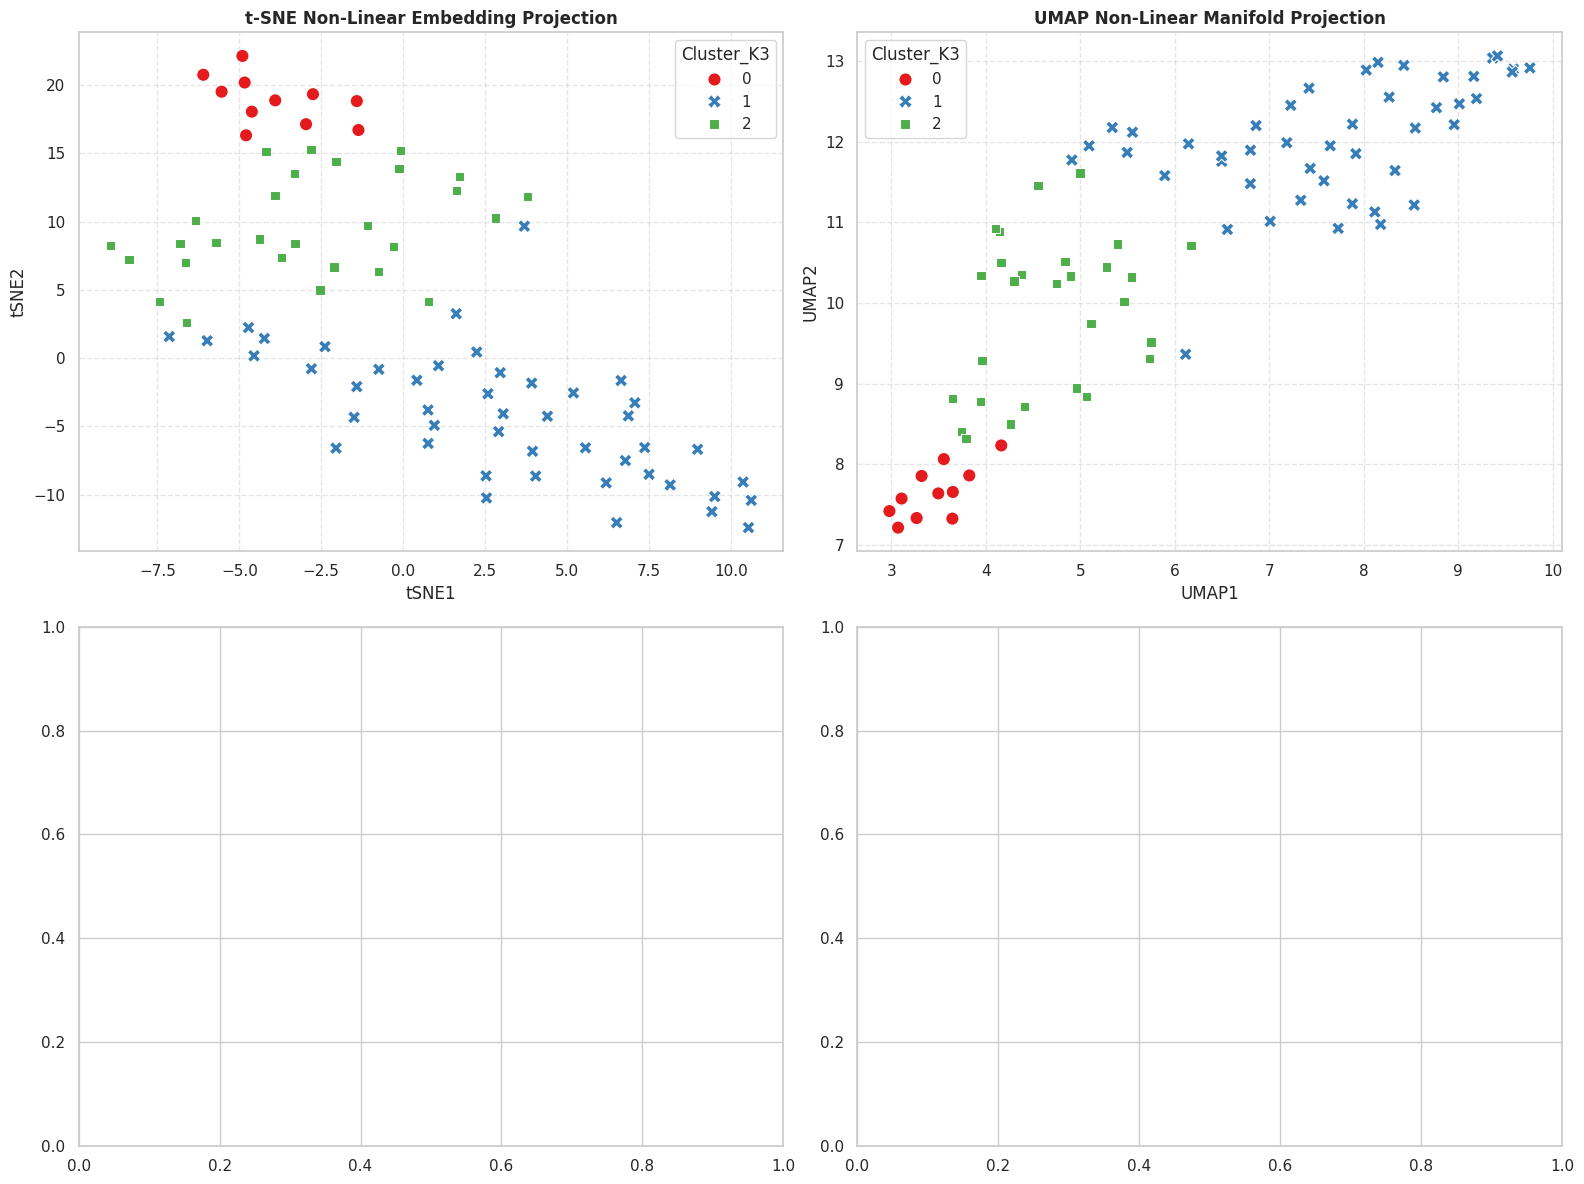

In [ ]:
#18
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Install umap-learn if not available
try:
    import umap
except ImportError:
    !pip install -q umap-learn
    import umap

# ---------------------------------------------------------
# 1. NON-LINEAR DIMENSIONALITY REDUCTION (t-SNE & UMAP)
# ---------------------------------------------------------
# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=15, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
final_dataset['tSNE1'] = X_tsne[:, 0]
final_dataset['tSNE2'] = X_tsne[:, 1]

# Apply UMAP
umap_model = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)
final_dataset['UMAP1'] = X_umap[:, 0]
final_dataset['UMAP2'] = X_umap[:, 1]


# ---------------------------------------------------------
# 3. VISUALIZATION DASHBOARD
# ---------------------------------------------------------
fig, axes = plt.subplots(2,2, figsize=(16, 12))

# Plot 1: t-SNE Non-Linear Manifold
sns.scatterplot(
    data=final_dataset, x='tSNE1', y='tSNE2', hue='Cluster_K3',
    palette='Set1', style='Cluster_K3', s=90, ax=axes[0, 0]
)
axes[0, 0].set_title('t-SNE Non-Linear Embedding Projection', fontweight='bold')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: UMAP Manifold
sns.scatterplot(
    data=final_dataset, x='UMAP1', y='UMAP2', hue='Cluster_K3',
    palette='Set1', style='Cluster_K3', s=90, ax=axes[0, 1]
)
axes[0, 1].set_title('UMAP Non-Linear Manifold Projection', fontweight='bold')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()



This notebook documents an unsupervised machine learning and hydrogeophysical classification framework applied to Vertical Electrical Sounding (VES) data from the Ilorin Basement Complex.

### Executive Summary

**Objective & Scope**
The analysis aims to categorize subsurface geoelectric profiles into distinct hydrogeological regimes using unsupervised clustering, replacing or enhancing manual 1D resistivity interpretation. The dataset consists of 85 soundings across 24 depth layers ($\text{AB/2}$ electrode spacings) coupled with geographic coordinates.

**Data Processing Pipeline**

* **Preprocessing:** Log-transformation ($\log_{10}(\rho_a + 10^{-6})$) and standard scaling were applied across all 24 depth features to reduce skewness in resistivity variations.
* **Dimensionality Reduction:** Principal Component Analysis (PCA) was performed, retaining **92.2% of total variance** (PC1: 75.8% explaining resistivity magnitude, PC2: 16.4% explaining depth trends/curve shapes).

---

### Model Evaluation & Selection

Multiple unsupervised algorithms were benchmarked on the standardized feature space:

| Clustering Algorithm | Key Findings & Cluster Distribution |
| --- | --- |
| **K-Means (Euclidean)** | **Primary Choice ($K=3$):** Cluster 0 ($n=11$), Cluster 1 ($n=46$), Cluster 2 ($n=28$). |
| **Fuzzy C-Means (FCM)** | Soft membership partition: Cluster 0 ($n=38$), Cluster 1 ($n=30$), Cluster 2 ($n=17$). |
| **Gaussian Mixture Model (GMM)** | Probabilistic grouping: Cluster 0 ($n=19$), Cluster 1 ($n=37$), Cluster 2 ($n=29$). |
| **DBSCAN (Pseudo-Series)** | Identified 1 primary dense cluster ($n=74$) and 11 noise/outlier stations. |

---

### Key Findings & Geoscience Justification

* **Validation Metrics:** While pure mathematical optimization suggests $K=2$ (Silhouette Score: 0.442), a **3-cluster model ($K=3$)** was chosen (Silhouette: 0.344, Davies-Bouldin: 1.052).
* **Geological Relevance ($K=3$):** A 2-cluster model oversimplifies the domain into conductive vs. resistive extremes. The 3-cluster partition successfully resolves the crucial **weathered/fractured intermediate layer**, which governs hydrogeologic potential in hard-rock basement terrains.
* **Model Stability:** 100-iteration bootstrap cross-validation yielded a **Mean Adjusted Rand Index (ARI) of 0.663**, confirming moderate-to-high boundary stability.

COMPREHENSIVE CLUSTERING REPORT
PCA Variance Explained: PC1 = 75.8%, PC2 = 16.4% (Total = 92.2%)
Silhouette Score (K=3): 0.344
Davies-Bouldin Index (K=3): 1.052
Mean Bootstrap ARI (100 Iterations): 0.663

Cluster Sizes (K-Means):
KMeans_Cluster
0    11
1    46
2    28
Name: count, dtype: int64

--- STATION CLUSTER ASSIGNMENTS TABLE ---
VES_ID  KMeans_Cluster
  VES1               2
  VES2               1
  VES3               2
  VES4               1
  VES5               1
  VES6               1
  VES7               1
  VES8               2
  VES9               1
 VES10               1
 VES11               1
 VES12               2
 VES13               2
 VES14               1
 VES15               2
 VES16               2
 VES17               2
 VES18               1
 VES19               2
 VES20               1
 VES21               1
 VES22               0
 VES23               0
 VES24               1
 VES25               2
 VES26               1
 VES27               1
 VES28            

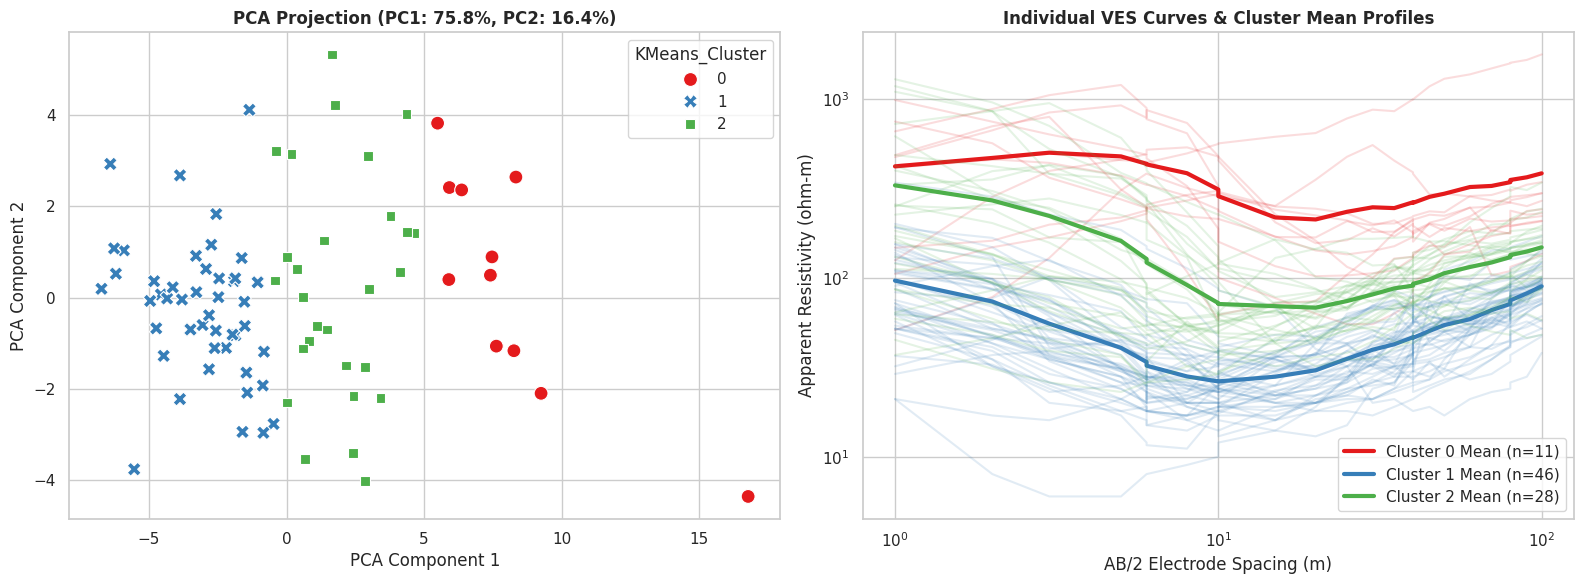

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.utils import resample
from scipy.spatial.distance import pdist, squareform

# Set random seeds for exact reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ==============================================================================
# 1. DATA PREPROCESSING & FEATURE MATRIX PREPARATION
# ==============================================================================
# Load raw dataset files
df_ves = pd.read_excel('vesdata.xlsx')
df_coord = pd.read_excel('Appendix_II_coordinates XY.xlsx')

# Clean column names for station consistency
df_ves = df_ves.rename(columns={'VES31.1': 'VES32', 'VES58.1': 'VES59'})
ab2_values = df_ves['Half AB'].values
ves_stations = [c for c in df_ves.columns if c != 'Half AB']

# Build raw matrix (85 stations x 24 depth layers)
X_raw = df_ves[ves_stations].values.T  # Shape: (85, 24)

# Preprocessing: Log-transformation log10(rho + 1e-6) followed by StandardScaler
X_log = np.log10(X_raw + 1e-6)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# ==============================================================================
# 2. DIMENSIONALITY REDUCTION (PCA) & PRIMARY K-MEANS CLUSTERING (K=3)
# ==============================================================================
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)
var_pc1, var_pc2 = pca.explained_variance_ratio_ * 100

# Primary Clustering: K-Means (K=3)
kmeans_k3 = KMeans(n_clusters=3, random_state=RANDOM_SEED, n_init=10)
kmeans_labels = kmeans_k3.fit_predict(X_scaled)

# Clustering Validation Metrics
sil_score = silhouette_score(X_scaled, kmeans_labels)
db_score = davies_bouldin_score(X_scaled, kmeans_labels)

# ==============================================================================
# 3. OTHER CLUSTERING ALGORITHMS & DBSCAN OUTLIER DETECTION
# ==============================================================================
# Pseudo-Series DBSCAN for spatial/depth profile outliers
dist_matrix = squareform(pdist(X_scaled, metric='euclidean'))
dbscan = DBSCAN(eps=2.5, min_samples=3, metric='precomputed')
dbscan_labels = dbscan.fit_predict(dist_matrix)

# ==============================================================================
# 4. CLUSTER STABILITY (CORRECTED BOOTSTRAP ARI PROCEDURE)
# ==============================================================================
# Bootstrap Procedure:
# 1. Fit reference baseline model on full dataset (K=3).
# 2. Resample 80% of dataset with replacement over 100 iterations.
# 3. Fit K-Means on bootstrap sample and evaluate Adjusted Rand Index (ARI)
#    against reference baseline on intersecting sample indices.
n_iterations = 100
ari_scores = []
for i in range(n_iterations):
    X_boot, boot_indices = resample(
        X_scaled, np.arange(len(X_scaled)),
        replace=True, n_samples=int(0.8 * len(X_scaled)),
        random_state=i
    )
    km_boot = KMeans(n_clusters=3, random_state=i, n_init=10)
    boot_labels = km_boot.fit_predict(X_boot)

    ref_sub_labels = kmeans_labels[boot_indices]
    ari_scores.append(adjusted_rand_score(ref_sub_labels, boot_labels))

mean_ari = np.mean(ari_scores)

# ==============================================================================
# 5. DATASET ASSEMBLY & CONSOLE REPORTING
# ==============================================================================
results_df = pd.DataFrame({
    'VES_ID': [s.strip() for s in ves_stations],
    'KMeans_Cluster': kmeans_labels,
    'DBSCAN_Cluster': dbscan_labels,
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1]
})

print("="*60)
print("COMPREHENSIVE CLUSTERING REPORT")
print("="*60)
print(f"PCA Variance Explained: PC1 = {var_pc1:.1f}%, PC2 = {var_pc2:.1f}% (Total = {var_pc1+var_pc2:.1f}%)")
print(f"Silhouette Score (K=3): {sil_score:.3f}")
print(f"Davies-Bouldin Index (K=3): {db_score:.3f}")
print(f"Mean Bootstrap ARI (100 Iterations): {mean_ari:.3f}")
print("\nCluster Sizes (K-Means):")
print(results_df['KMeans_Cluster'].value_counts().sort_index())

print("\n--- STATION CLUSTER ASSIGNMENTS TABLE ---")
print(results_df[['VES_ID', 'KMeans_Cluster']].to_string(index=False))

# DBSCAN Outliers
dbscan_outliers = results_df[results_df['DBSCAN_Cluster'] == -1]['VES_ID'].tolist()
print("\n--- DBSCAN OUTLIERS / NOISE STATIONS ---")
print(f"Total Outliers: {len(dbscan_outliers)}")
print(f"Stations: {', '.join(dbscan_outliers)}")

# Mean/Median Log-Resistivity Profiles
print("\n--- MEAN LOG-RESISTIVITY PROFILES PER CLUSTER ---")
for c in sorted(results_df['KMeans_Cluster'].unique()):
    idx = results_df[results_df['KMeans_Cluster'] == c].index
    mean_log = np.mean(X_log[idx, :], axis=0)
    print(f"\nCluster {c} Mean Log10 Profile (24 points):")
    print(np.round(mean_log, 3))

# ==============================================================================
# 6. VISUALIZATIONS
# ==============================================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: PCA Feature Space Projection
sns.scatterplot(
    data=results_df, x='PCA1', y='PCA2', hue='KMeans_Cluster',
    palette='Set1', style='KMeans_Cluster', s=100, ax=axes[0]
)
axes[0].set_title(f'PCA Projection (PC1: {var_pc1:.1f}%, PC2: {var_pc2:.1f}%)', fontweight='bold')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')

# Plot 2: VES Curves per Cluster with Mean Profiles
palette = sns.color_palette('Set1', 3)
for c in sorted(results_df['KMeans_Cluster'].unique()):
    idx = results_df[results_df['KMeans_Cluster'] == c].index
    # Individual curves (faded)
    for i in idx:
        axes[1].loglog(ab2_values, X_raw[i, :], color=palette[c], alpha=0.15)
    # Mean curve (bold)
    mean_profile = np.mean(X_raw[idx, :], axis=0)
    axes[1].loglog(
        ab2_values, mean_profile, color=palette[c],
        linewidth=3, label=f'Cluster {c} Mean (n={len(idx)})'
    )

axes[1].set_title('Individual VES Curves & Cluster Mean Profiles', fontweight='bold')
axes[1].set_xlabel('AB/2 Electrode Spacing (m)')
axes[1].set_ylabel('Apparent Resistivity (ohm-m)')
axes[1].legend()

plt.tight_layout()
plt.show()